# 07 — Transaction-cost sweep + capacity (Phase D-2)

Net Sharpe at fixed cost assumptions (0/5/10/20 bps round-trip), capacity curve
via square-root-impact-law extrapolation, on the headline `rung_6w` strategy.

**IMPORTANT CAVEAT — turnover is ASSUMED, not measured.** Current runner does
not save per-rebal weights, so we can't compute exact turnover from the cached
outputs. We use a proxy: monthly rebal with dual-softmax-winsor recasts most
positions each month. We show three scenarios — worst case (1.0/rebal),
realistic (0.7/rebal), and optimistic (0.5/rebal). Instrument the runner to
save weights for an exact number.

**Pass criterion for D-2:** net Sharpe ≥ 0.3 at 10 bps round-trip cost under
the realistic turnover scenario (0.7/rebal) → investable at typical TCs.


In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import config, eval as evalmod


## 1. Build daily-returns and synthetic turnover for the headline

Each rebal date in `all_results.csv` becomes a turnover event. We assign the
same proxy turnover at every rebal (constant — no model-driven variation).


In [2]:
HEADLINE = 'rung_6w_tcnn_3ch_winsor'

master = evalmod.load_master_results([HEADLINE])
master['date'] = pd.to_datetime(master['date'])
master['rebal_date'] = pd.to_datetime(master['rebal_date'])

# Daily returns series (single seed, no averaging needed)
daily_returns = master.set_index('date')['return'].sort_index()
print(f'daily returns: {len(daily_returns):,} days,  {daily_returns.index.min().date()} -> {daily_returns.index.max().date()}')

# Rebal events: turnover cost is incurred on the FIRST trading day of each holding period
# (not on rebal_date itself, which is the last day of month T; trading happens at T+1)
entry_dates = master.groupby('rebal_date')['date'].min().sort_values()
print(f'rebal events: {len(entry_dates)} (expected ~14 yr * 12 = 168 monthly events)')
print(f'first 3 entry dates: {list(entry_dates.head(3))}')


daily returns: 3,336 days,  2010-01-30 -> 2023-12-19
rebal events: 167 (expected ~14 yr * 12 = 168 monthly events)
first 3 entry dates: [Timestamp('2010-01-30 00:00:00'), Timestamp('2010-02-27 00:00:00'), Timestamp('2010-04-01 00:00:00')]


## 2. TC sweep — three turnover scenarios × four cost levels

`one_way_turnover_per_rebal` is the proxy (gross_leverage = 1.0 in our config):
- **1.0/rebal** — worst case: 100% recast every month, zero stock-level persistence
- **0.7/rebal** — realistic: typical for monthly-rebal momentum (some persistent tails)
- **0.5/rebal** — optimistic: high persistence, only 50% of weight rebalances


In [3]:
TURNOVER_SCENARIOS = {
    'worst (1.0/rebal)':       1.0,
    'realistic (0.7/rebal)':   0.7,
    'optimistic (0.5/rebal)':  0.5,
}
COST_GRID = (0, 5, 10, 20)  # round-trip bps

sweeps = {}
for label, t_per_rebal in TURNOVER_SCENARIOS.items():
    # Turnover indexed by entry_dates (first trading day of each holding period) so the
    # cost subtraction in eval.net_returns_under_cost actually lands on a real return date.
    turnover = pd.Series(t_per_rebal, index=pd.DatetimeIndex(entry_dates.values))
    sw = evalmod.tc_sweep(daily_returns, turnover, cost_grid_bps=COST_GRID)
    sw.insert(0, 'scenario', label)
    sweeps[label] = sw

tc_table = pd.concat(sweeps.values(), ignore_index=True)
print(tc_table.round(3).to_string(index=False))

# D-2 gate
gate = tc_table[(tc_table['scenario'] == 'realistic (0.7/rebal)') & (tc_table['cost_bps'] == 10)]
gate_sr = float(gate['sharpe'].iloc[0])
print(f"\nD-2 gate: realistic-turnover × 10 bps cost net Sharpe = {gate_sr:.3f}  (need >= 0.30)")
print('D-2 PASS' if gate_sr >= 0.30 else 'D-2 FAIL — strategy too costly under realistic TC assumption')


              scenario  cost_bps  sharpe  ann_return  max_dd  ann_turnover_pct
     worst (1.0/rebal)         0   0.662       0.021  -0.054          1202.854
     worst (1.0/rebal)         5   0.469       0.015  -0.065          1202.854
     worst (1.0/rebal)        10   0.275       0.009  -0.079          1202.854
     worst (1.0/rebal)        20  -0.106      -0.004  -0.105          1202.854
 realistic (0.7/rebal)         0   0.662       0.021  -0.054           841.998
 realistic (0.7/rebal)         5   0.527       0.017  -0.061           841.998
 realistic (0.7/rebal)        10   0.391       0.012  -0.071           841.998
 realistic (0.7/rebal)        20   0.121       0.003  -0.089           841.998
optimistic (0.5/rebal)         0   0.662       0.021  -0.054           601.427
optimistic (0.5/rebal)         5   0.566       0.018  -0.058           601.427
optimistic (0.5/rebal)        10   0.469       0.015  -0.065           601.427
optimistic (0.5/rebal)        20   0.275       0.009

## 3. Capacity curve (sqrt-impact law)

How does net Sharpe degrade as we scale AUM? Uses the standard sqrt-law:
`cost_bps(AUM) = base_cost * (AUM / base_AUM) ** 0.5`. Anchored at $50M AUM,
10 bps base cost. Realistic turnover scenario (0.7/rebal).


 aum_usd_M  cost_bps  sharpe  ann_return  max_dd
      50.0    10.000   0.391       0.012  -0.071
     200.0    20.000   0.121       0.003  -0.089
     500.0    31.623  -0.186      -0.007  -0.119
    1000.0    44.721  -0.517      -0.018  -0.227
    2000.0    63.246  -0.947      -0.034  -0.376
    5000.0   100.000  -1.639      -0.065  -0.593



Maximum AUM where net Sharpe stays >= 0.30: $50M


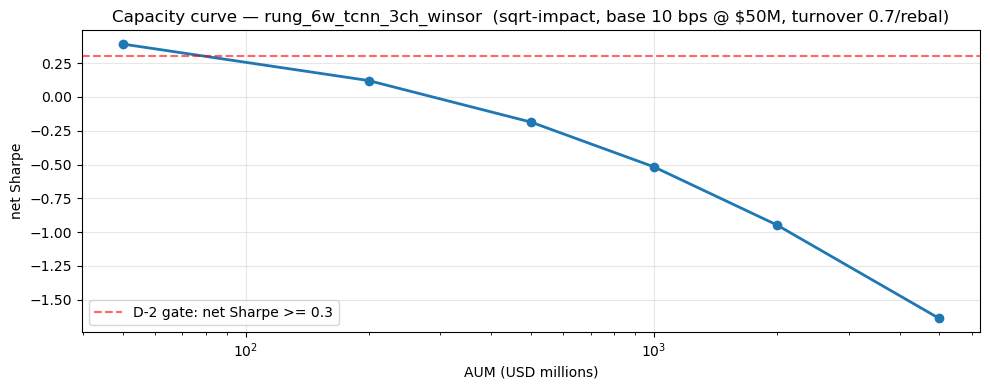

In [4]:
REALISTIC_TURNOVER = 0.7
turnover_realistic = pd.Series(REALISTIC_TURNOVER, index=pd.DatetimeIndex(entry_dates.values))

cap = evalmod.capacity_curve(
    daily_returns, turnover_realistic,
    aum_grid_usd=(50e6, 200e6, 500e6, 1e9, 2e9, 5e9),
    base_aum_usd=50e6,
    base_cost_bps_round_trip=10.0,
    impact_exponent=0.5,
)
cap_display = cap.copy()
cap_display['aum_usd_M'] = cap_display['aum_usd'] / 1e6
cap_display = cap_display[['aum_usd_M', 'cost_bps', 'sharpe', 'ann_return', 'max_dd']]
print(cap_display.round(3).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cap['aum_usd']/1e6, cap['sharpe'], marker='o', linewidth=2)
ax.axhline(0.30, color='r', linestyle='--', alpha=0.6, label='D-2 gate: net Sharpe >= 0.3')
ax.set(xscale='log', xlabel='AUM (USD millions)', ylabel='net Sharpe',
       title=f'Capacity curve — {HEADLINE}  (sqrt-impact, base 10 bps @ $50M, turnover 0.7/rebal)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()

# Find break-even AUM
above = cap[cap['sharpe'] >= 0.30]
if len(above):
    last = above['aum_usd'].max() / 1e6
    print(f'\nMaximum AUM where net Sharpe stays >= 0.30: ${last:.0f}M')
else:
    print('\nWARN: net Sharpe < 0.30 even at smallest AUM — TC drag dominates.')
